In [105]:
import numpy as np
import gymnasium as gym
import importlib
import envs

from qrtd import Params

params = Params(
    model_name="WindyRooms",
    n_runs=3,
    n_episodes=50_000,
    save_skip=100,
    lr_decay=None,
    seed=123,
    
    N=32,
    # alpha=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.2,1.5,1.8,2.0,5.0],
    alpha=1.0,
    gamma=0.99,
    epsilon=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(params.model_name)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

save_to = None#"experiments/"+params.model_name

In [106]:
import analysis
import qrtd
importlib.reload(analysis)
importlib.reload(qrtd)

from learners import PolicyIteration, MonteCarlo
from analysis import *
from qrtd import train_qrtd

policy, V_pi = PolicyIteration(env, params.gamma)
table_qrtd0 = train_qrtd(env, policy, params, kappa=0, rho_type="")
# table_qrtd1 = train_qrtd(env, policy, params, kappa=1, rho_type="")

# params_td = params._replace(N=1)
# table_td = train_qrtd(env, policy, params_td, rho_type="td")

returns = MonteCarlo(env, policy, params.gamma, total_episodes=5_000)
tau_returns = np.quantile(np.sort(returns), tau)

100%|██████████| 5000/5000 [00:00<00:00, 5889.40it/s]


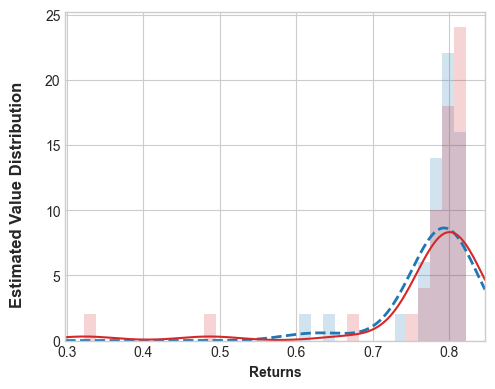

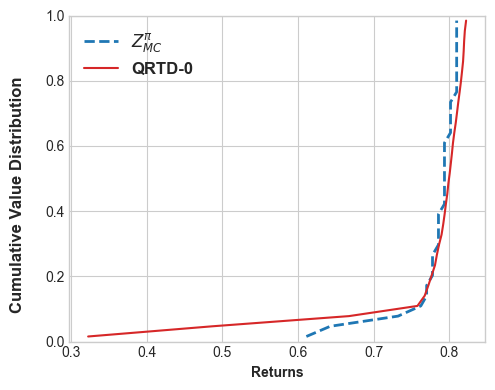

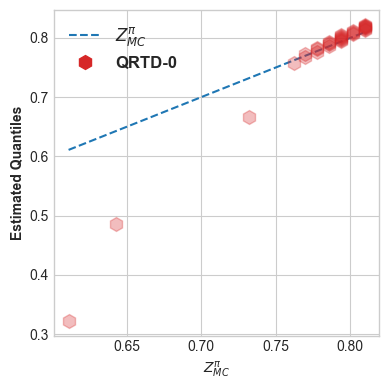

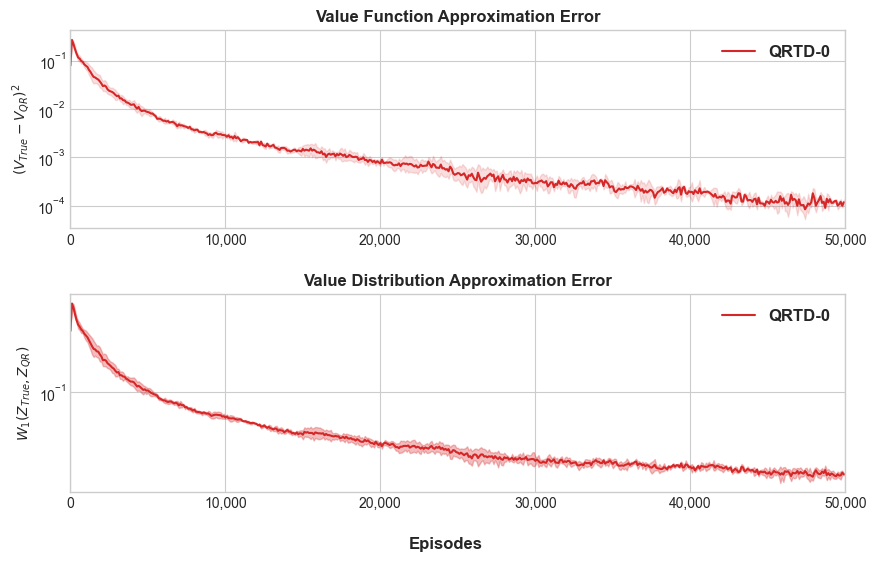

In [107]:
init_qrtd0 = table_qrtd0[-1][-1,s_init]
# init_qrtd1 = table_qrtd1[-1][-1,s_init]

plot_objs = [
    (init_qrtd0, "QRTD-0"),
    # (init_qrtd1, "QRTD-1"),
]
# plot_qs = [(table_qrtd0[i::len(params.alpha),:,s_init], "QRTD-0"+f"-{alpha}") for i, alpha in enumerate(params.alpha)]
plot_qs = [
    (table_qrtd0[:,:,s_init], "QRTD-0"),
    # (table_qrtd1[:,:,s_init], "QRTD-1"),
    # (table_td[:,:,s_init], "TD"),
]

LOW_BANDWIDTH = 0.004
plot_pdf(plot_objs, tau_returns, bandwidth=0.04, show_hist=True, N=params.N, save_to=save_to)
plot_cdf(plot_objs, tau_returns, tau, save_to=save_to)
plot_qq(plot_objs, tau_returns, save_to=save_to)
plot_metrics(plot_qs, tau_returns, save_skip=params.save_skip, save_to=save_to, alphas=[0.15,0.3])

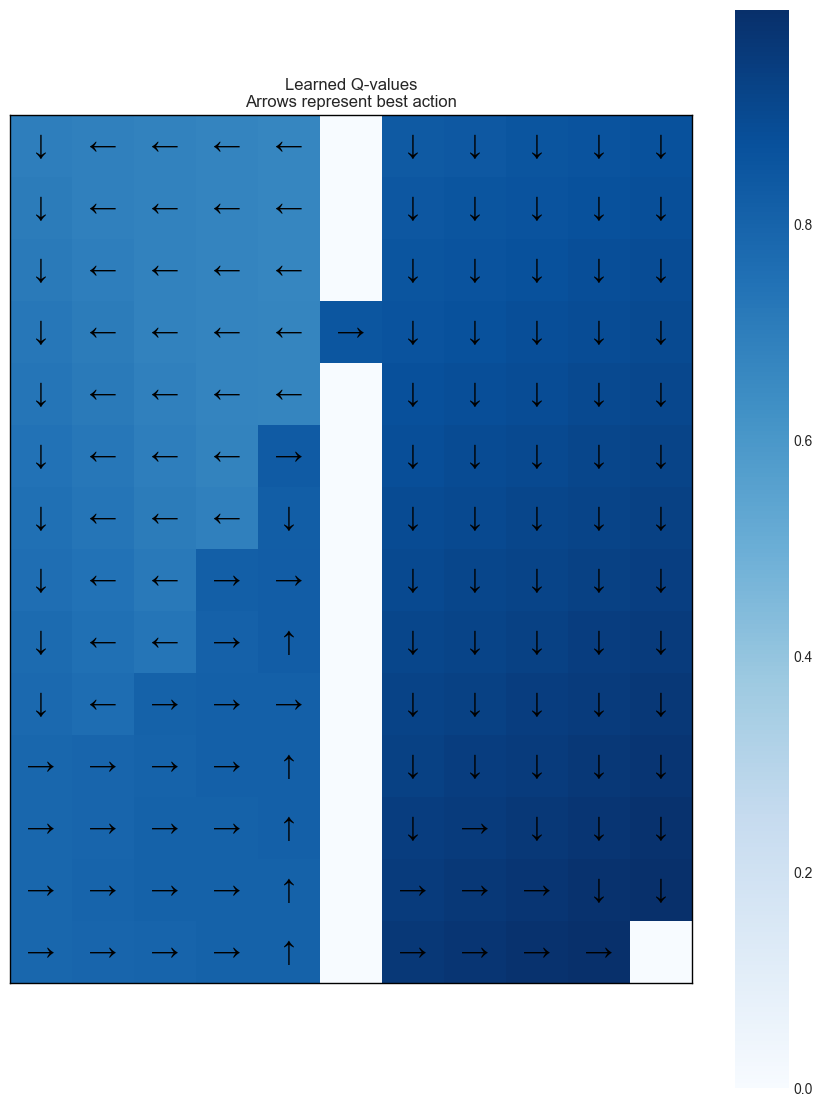

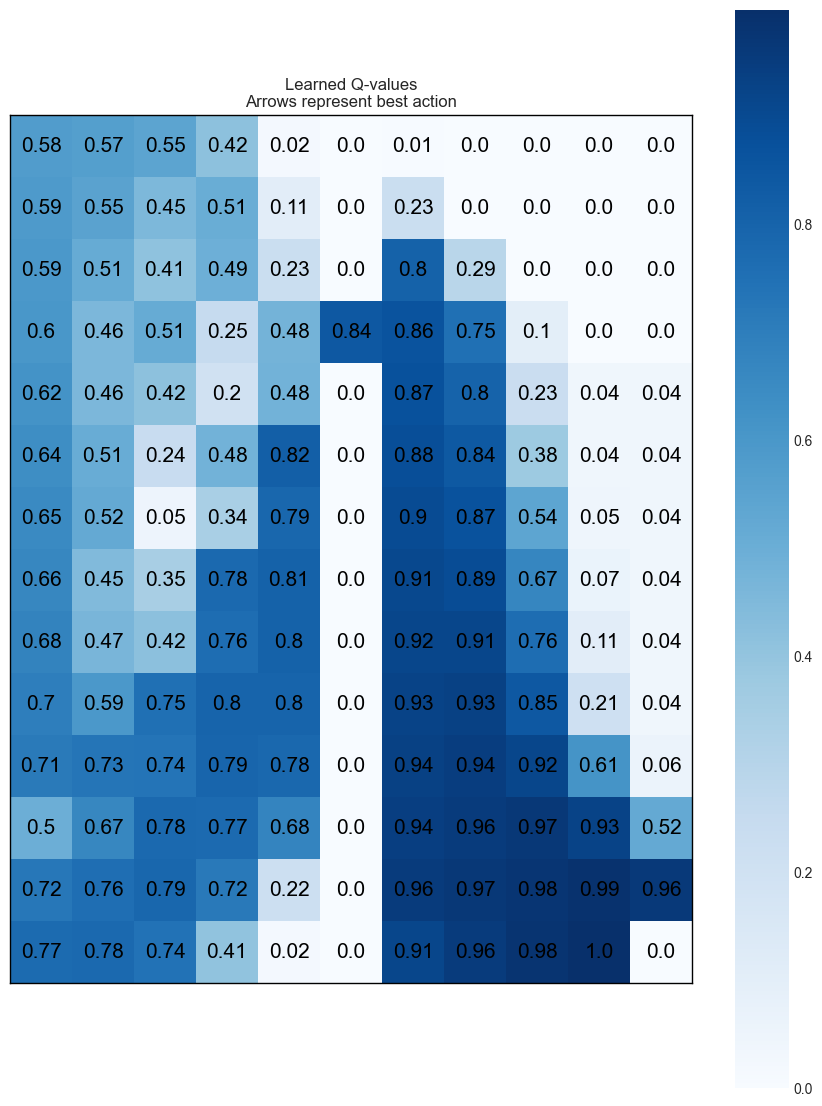

In [108]:
plot_map(policy, params, is_policy=True, V=V_pi)
# plot_map(table_qrtd0[0,-1,:,:params.N//2].mean(-1), params)
plot_map(table_qrtd0[0,-1].mean(-1), params)